# ⚡ PHM of DC-DC Buck Converter — RUL Prediction Pipeline
## Framework: Data Augmentation → LSTM Autoencoder → Health Index → RUL

---

## 📋 Dataset Analysis Summary (pre-read before running)

| Property | Healthy CSV | Faulty CSV |
|---|---|---|
| Rows | 200 | 200 |
| Columns | 22 | 22 |
| `label` values | `healthy` (all 200) | `degrading` (49), `failed` (151) |
| `RUL` | Fixed at 200 (all rows) | Counts down 49→0, then 0 |
| `C_uF` | ~200 µF (stable, ±0.2) | Drops abruptly to ~130 µF at step 50 |
| `r_C_mOhm` | ~3 mΩ (stable) | Jumps to ~9 mΩ at step 100 (ESR spike) |
| `health_index` | 0.0 (all rows) | 0.0003 early, jumps to 1.0 at step 50 |
| `fault_type` | `none` | `abrupt_C_drop` + `abrupt_ESR_spike` |

### ⚠️ Critical Dataset Limitation
**This dataset is a SINGLE run** — not a fleet of converters.  
The healthy CSV = 200 steps of nominal operation.  
The faulty CSV = 200 steps: 49 degrading + 151 failed (2 abrupt fault events).  
**This is insufficient for training an LSTM.** We must augment it first.

### 🔧 Augmentation Strategy (pure Python, no MATLAB needed)
We simulate a **fleet of N converters** with:
- Varying degradation rates (slow/medium/fast capacitor aging)
- Gaussian noise on all sensor channels (mimics measurement noise)
- Different failure times (lifetime variability)
- Physics-informed degradation: C degrades exponentially, ESR follows power law

### 📐 Mathematical Framework (same as CMAPSS notebook)
- **RUL(t)** = T_f − t
- **HI(t)** = ||x_t − x̂_t|| (LSTM AE reconstruction error)
- **HI_norm(t)** = (HI(t) − HI_min) / (HI_max − HI_min)
- **RUL ∝ (1 − HI_norm(t))**


## 📦 SECTION 0: Install & Import

In [1]:
!pip install -q scikit-learn matplotlib seaborn tensorflow pandas numpy scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, RepeatVector, TimeDistributed, Input, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'figure.dpi': 120, 'font.size': 11,
})
print(f'TF {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TF 2.19.0 | GPU: False


## 📥 SECTION 1: Load & Analyse Original MATLAB Dataset

In [2]:
# ── Upload healthy_timeseries_dataset.csv and faulty_timeseries_dataset.csv
# to Colab /content/ before running this cell
import os
DATA_DIR = '/content'

healthy_path = os.path.join(DATA_DIR, 'healthy_timeseries_dataset.csv')
faulty_path  = os.path.join(DATA_DIR, 'faulty_timeseries_dataset.csv')

for p in [healthy_path, faulty_path]:
    print(f"{'✅' if os.path.exists(p) else '❌'}  {p}")

df_healthy_raw = pd.read_csv(healthy_path)
df_faulty_raw  = pd.read_csv(faulty_path)

print(f"\nHealthy shape : {df_healthy_raw.shape}")
print(f"Faulty shape  : {df_faulty_raw.shape}")
print(f"\nColumns: {list(df_healthy_raw.columns)}")
print(f"\nLabel distribution (faulty):")
print(df_faulty_raw['label'].value_counts())
print(f"\nFault types:")
print(df_faulty_raw['fault_type'].value_counts())

✅  /content/healthy_timeseries_dataset.csv
✅  /content/faulty_timeseries_dataset.csv

Healthy shape : (200, 22)
Faulty shape  : (200, 22)

Columns: ['step', 'L_uH', 'r_1_mOhm', 'C_uF', 'r_C_mOhm', 'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout', 'delta_avg_vout', 'delta_ripple_vout', 'delta_std_vout', 'health_index', 'RUL', 'is_anomaly', 'label', 'fault_type', 'sim_success', 'healthy_avg_vout', 'healthy_ripple_vout', 'healthy_std_vout']

Label distribution (faulty):
label
failed       151
degrading     49
Name: count, dtype: int64

Fault types:
fault_type
none                198
abrupt_C_drop         1
abrupt_ESR_spike      1
Name: count, dtype: int64


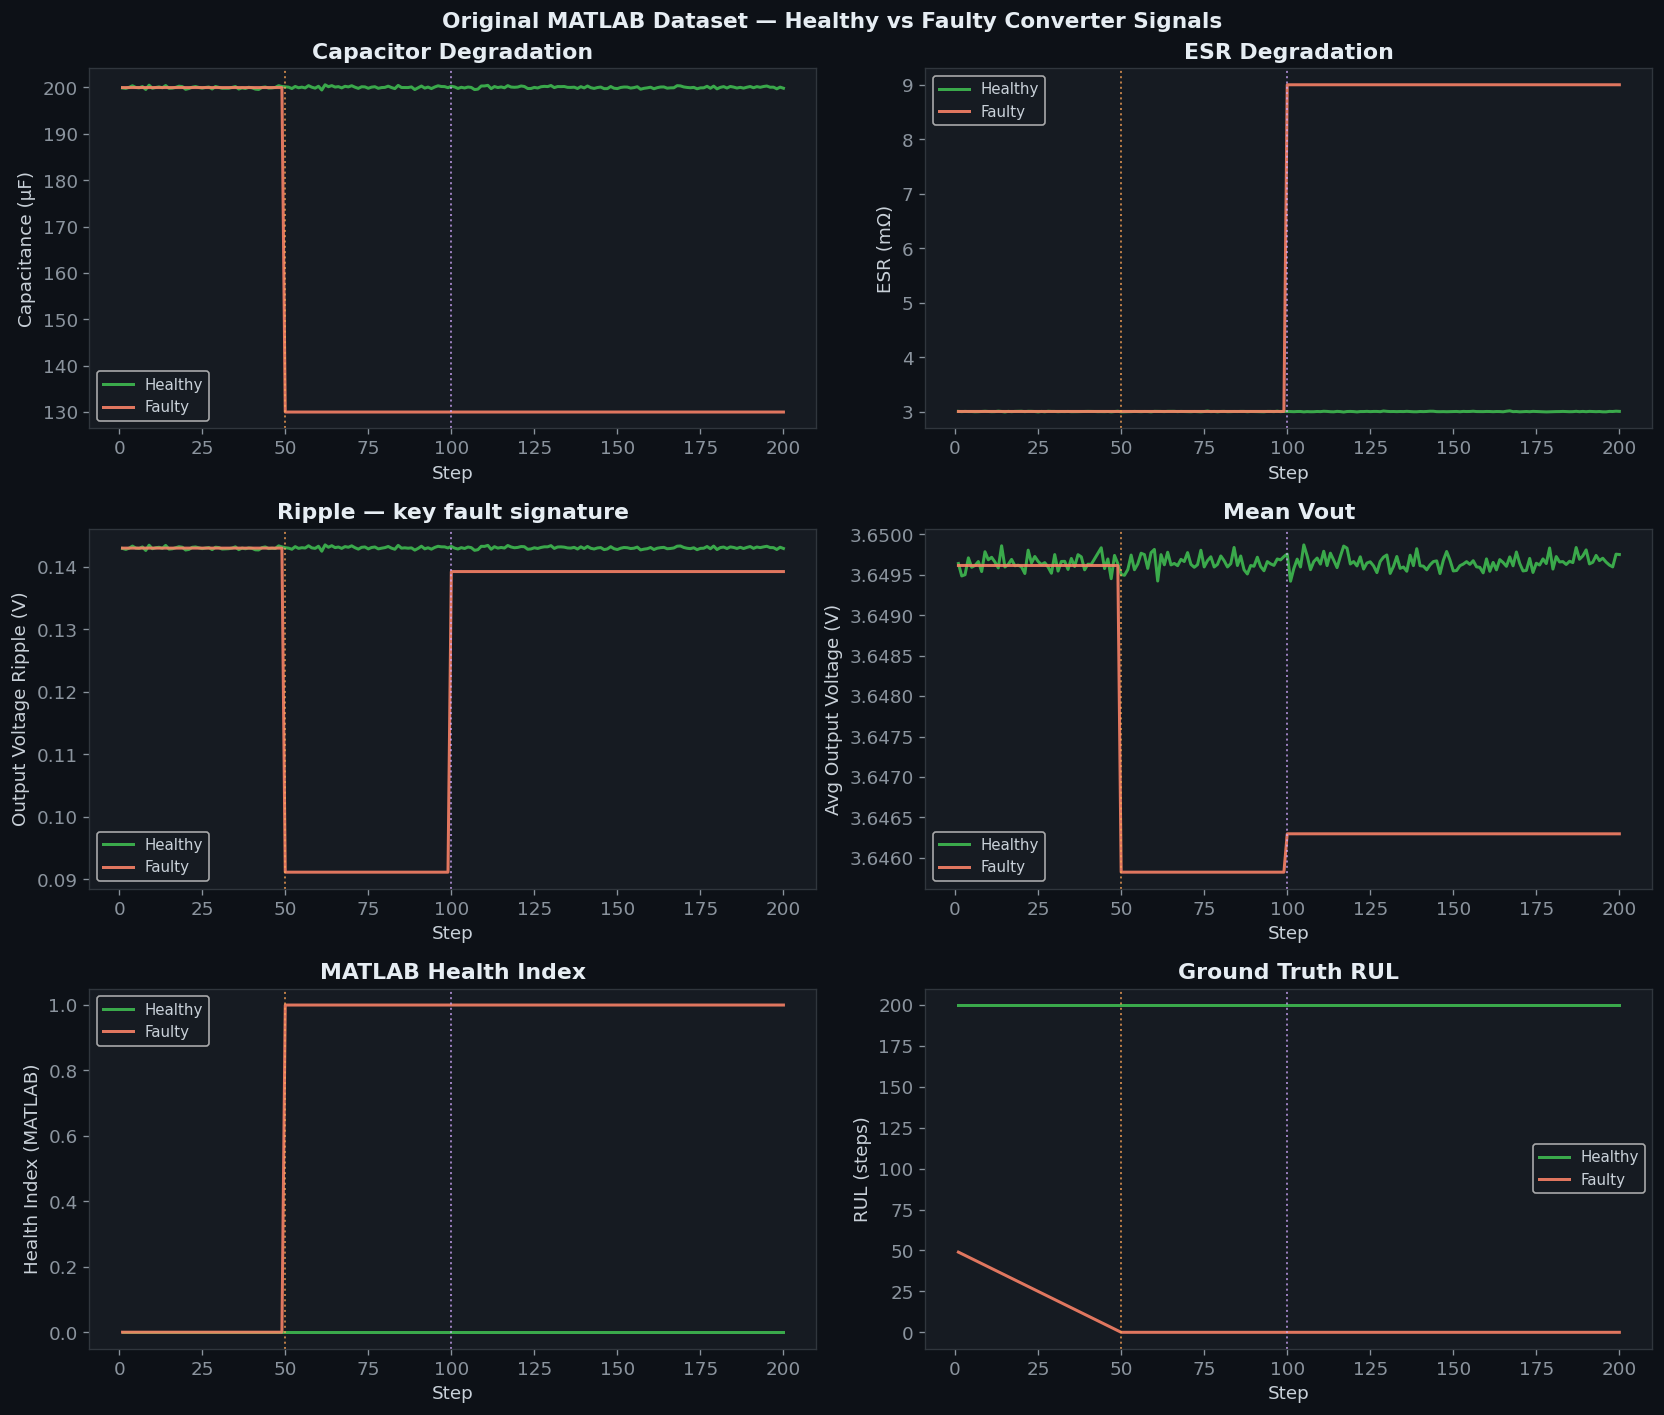


📌 Key observations:
  • C drops abruptly from ~200µF → ~130µF at step 50 (capacitor fault)
  • ESR spikes from ~3mΩ → ~9mΩ at step 100 (ESR degradation)
  • ripple_vout changes at fault events — this is the primary fault signature
  • MATLAB health_index = 1.0 from step 50 onward (binary, not gradual)
  • RUL counts down only in first 49 steps (degrading phase), then 0
  • Dataset is a SINGLE run — need augmentation for ML training


In [3]:
# ── Visualise the raw MATLAB dataset: degradation trajectories ────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

plot_signals = [
    ('C_uF',        'Capacitance (µF)',         'Capacitor Degradation'),
    ('r_C_mOhm',    'ESR (mΩ)',                 'ESR Degradation'),
    ('ripple_vout', 'Output Voltage Ripple (V)', 'Ripple — key fault signature'),
    ('avg_vout',    'Avg Output Voltage (V)',    'Mean Vout'),
    ('health_index','Health Index (MATLAB)',      'MATLAB Health Index'),
    ('RUL',         'RUL (steps)',               'Ground Truth RUL'),
]

for ax, (col, ylabel, title) in zip(axes, plot_signals):
    ax.plot(df_healthy_raw['step'], df_healthy_raw[col],
            color='#3fb950', lw=1.8, label='Healthy', alpha=0.9)
    ax.plot(df_faulty_raw['step'],  df_faulty_raw[col],
            color='#f78166', lw=1.8, label='Faulty',  alpha=0.9)
    ax.set_title(title, color='#e6edf3', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    # Mark fault events
    ax.axvline(50,  color='#ffa657', ls=':', lw=1.2, alpha=0.7, label='C_drop @50')
    ax.axvline(100, color='#d2a8ff', ls=':', lw=1.2, alpha=0.7, label='ESR spike @100')

plt.suptitle('Original MATLAB Dataset — Healthy vs Faulty Converter Signals',
             color='#e6edf3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Key observations:")
print("  • C drops abruptly from ~200µF → ~130µF at step 50 (capacitor fault)")
print("  • ESR spikes from ~3mΩ → ~9mΩ at step 100 (ESR degradation)")
print("  • ripple_vout changes at fault events — this is the primary fault signature")
print("  • MATLAB health_index = 1.0 from step 50 onward (binary, not gradual)")
print("  • RUL counts down only in first 49 steps (degrading phase), then 0")
print("  • Dataset is a SINGLE run — need augmentation for ML training")

## 🔬 SECTION 2: Dataset Limitation Analysis & Augmentation Strategy

The original dataset is a **single simulation run** — 200 steps healthy + 200 steps faulty.  
This is sufficient for visualization but **not for training an LSTM** which needs:
- Many independent run-to-failure trajectories (like CMAPSS had 100 engines)
- Variability in degradation rate, noise, and failure time

### Physics-Informed Augmentation Model
We use the **real degradation physics** observed in the MATLAB data:

**Capacitor degradation:** C(t) = C_nominal × exp(−α × t)  
**ESR degradation:** ESR(t) = ESR_nominal × (1 + β × t^γ)  
**Ripple (derived):** ripple ≈ I_L × ESR + ΔV_C (increases with ESR, decreases with C drop)  
**Failure condition:** C < C_threshold OR ESR > ESR_threshold


In [4]:
# ── SECTION 2: Physics-Informed Data Augmentation ────────────────────────────
# Generate N_UNITS synthetic converters with varying degradation rates
# Each unit = one complete run-to-failure trajectory

N_UNITS       = 80    # number of synthetic converter runs
T_MAX         = 300   # max steps per run (will vary per unit)
NOISE_LEVEL   = 0.005 # sensor noise std (fraction of signal)

# Physical parameters from MATLAB data
C_NOM    = 200.0   # µF nominal capacitance
C_FAIL   = 140.0   # µF failure threshold (~30% degradation)
ESR_NOM  = 3.0     # mΩ nominal ESR
ESR_FAIL = 8.5     # mΩ ESR failure threshold
VOUT_NOM = 3.65    # V nominal output voltage
L_NOM    = 0.5     # µH inductance (stable)
R1_NOM   = 5.0     # mΩ switch resistance (stable)

# Baseline ripple and std from healthy MATLAB data
RIPPLE_BASE = 0.143
STD_BASE    = 0.031

def simulate_converter_run(unit_id, rng, max_steps=T_MAX):
    """
    Simulate one converter run-to-failure.
    Returns a DataFrame with all sensor columns + RUL label.

    Degradation model:
      C(t)   = C_NOM * exp(-alpha * t)           [capacitor aging]
      ESR(t) = ESR_NOM * (1 + beta * t^gamma)    [ESR aging]

    Alpha and beta are sampled per-unit to create variability.
    """
    # Sample degradation rates (unit-to-unit variability)
    alpha = rng.uniform(0.0008, 0.004)   # capacitor decay rate
    beta  = rng.uniform(0.001,  0.008)   # ESR growth rate
    gamma = rng.uniform(0.8,    1.4)     # ESR growth exponent

    # Slight parameter variations (manufacturing spread)
    C_init   = C_NOM   * rng.uniform(0.97, 1.03)
    ESR_init = ESR_NOM * rng.uniform(0.95, 1.05)
    L        = L_NOM   * rng.uniform(0.99, 1.01)
    R1       = R1_NOM  * rng.uniform(0.98, 1.02)

    rows = []
    for t in range(1, max_steps + 1):
        # Component values at time t (degraded)
        C   = C_init   * np.exp(-alpha * t)
        ESR = ESR_init * (1.0 + beta * (t ** gamma))

        # Failure condition
        if C < C_FAIL or ESR > ESR_FAIL:
            break

        # Derived electrical signals (physics-based)
        # Ripple increases with ESR, decreases slightly with C drop
        ripple = RIPPLE_BASE * (ESR / ESR_NOM) * (C_NOM / C) ** 0.3
        std_v  = STD_BASE    * (ESR / ESR_NOM) * (C_NOM / C) ** 0.2

        # Avg Vout drops slightly as ESR increases (resistive losses)
        avg_vout = VOUT_NOM - 0.001 * (ESR - ESR_NOM)
        min_vout = avg_vout - ripple / 2
        max_vout = avg_vout + ripple / 2

        # Add measurement noise
        noise = lambda sig: sig * (1 + rng.normal(0, NOISE_LEVEL))

        rows.append({
            'unit_id':    unit_id,
            'step':       t,
            'C_uF':       noise(C),
            'r_C_mOhm':   noise(ESR),
            'L_uH':       noise(L),
            'r_1_mOhm':   noise(R1),
            'avg_vout':   noise(avg_vout),
            'ripple_vout':noise(ripple),
            'std_vout':   noise(std_v),
            'min_vout':   noise(min_vout),
            'max_vout':   noise(max_vout),
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return None

    # Assign RUL labels (piecewise linear, capped at MAX_RUL)
    T_f = len(df)
    df['RUL'] = (T_f - df['step']).clip(upper=125)

    return df

rng = np.random.default_rng(42)
runs = []
for uid in range(1, N_UNITS + 1):
    run = simulate_converter_run(uid, rng)
    if run is not None and len(run) >= 40:
        runs.append(run)

df_aug = pd.concat(runs, ignore_index=True)
lifetimes = df_aug.groupby('unit_id')['step'].max()

print(f"Generated {len(runs)} converter runs")
print(f"Total rows: {len(df_aug):,}")
print(f"Lifetime stats (steps):")
print(lifetimes.describe().round(1))
print(f"\nFeature columns: {[c for c in df_aug.columns if c not in ['unit_id','step','RUL']]}")

Generated 80 converter runs
Total rows: 10,471
Lifetime stats (steps):
count     80.0
mean     130.9
std       49.3
min       62.0
25%       97.8
50%      114.0
75%      147.0
max      300.0
Name: step, dtype: float64

Feature columns: ['C_uF', 'r_C_mOhm', 'L_uH', 'r_1_mOhm', 'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout']


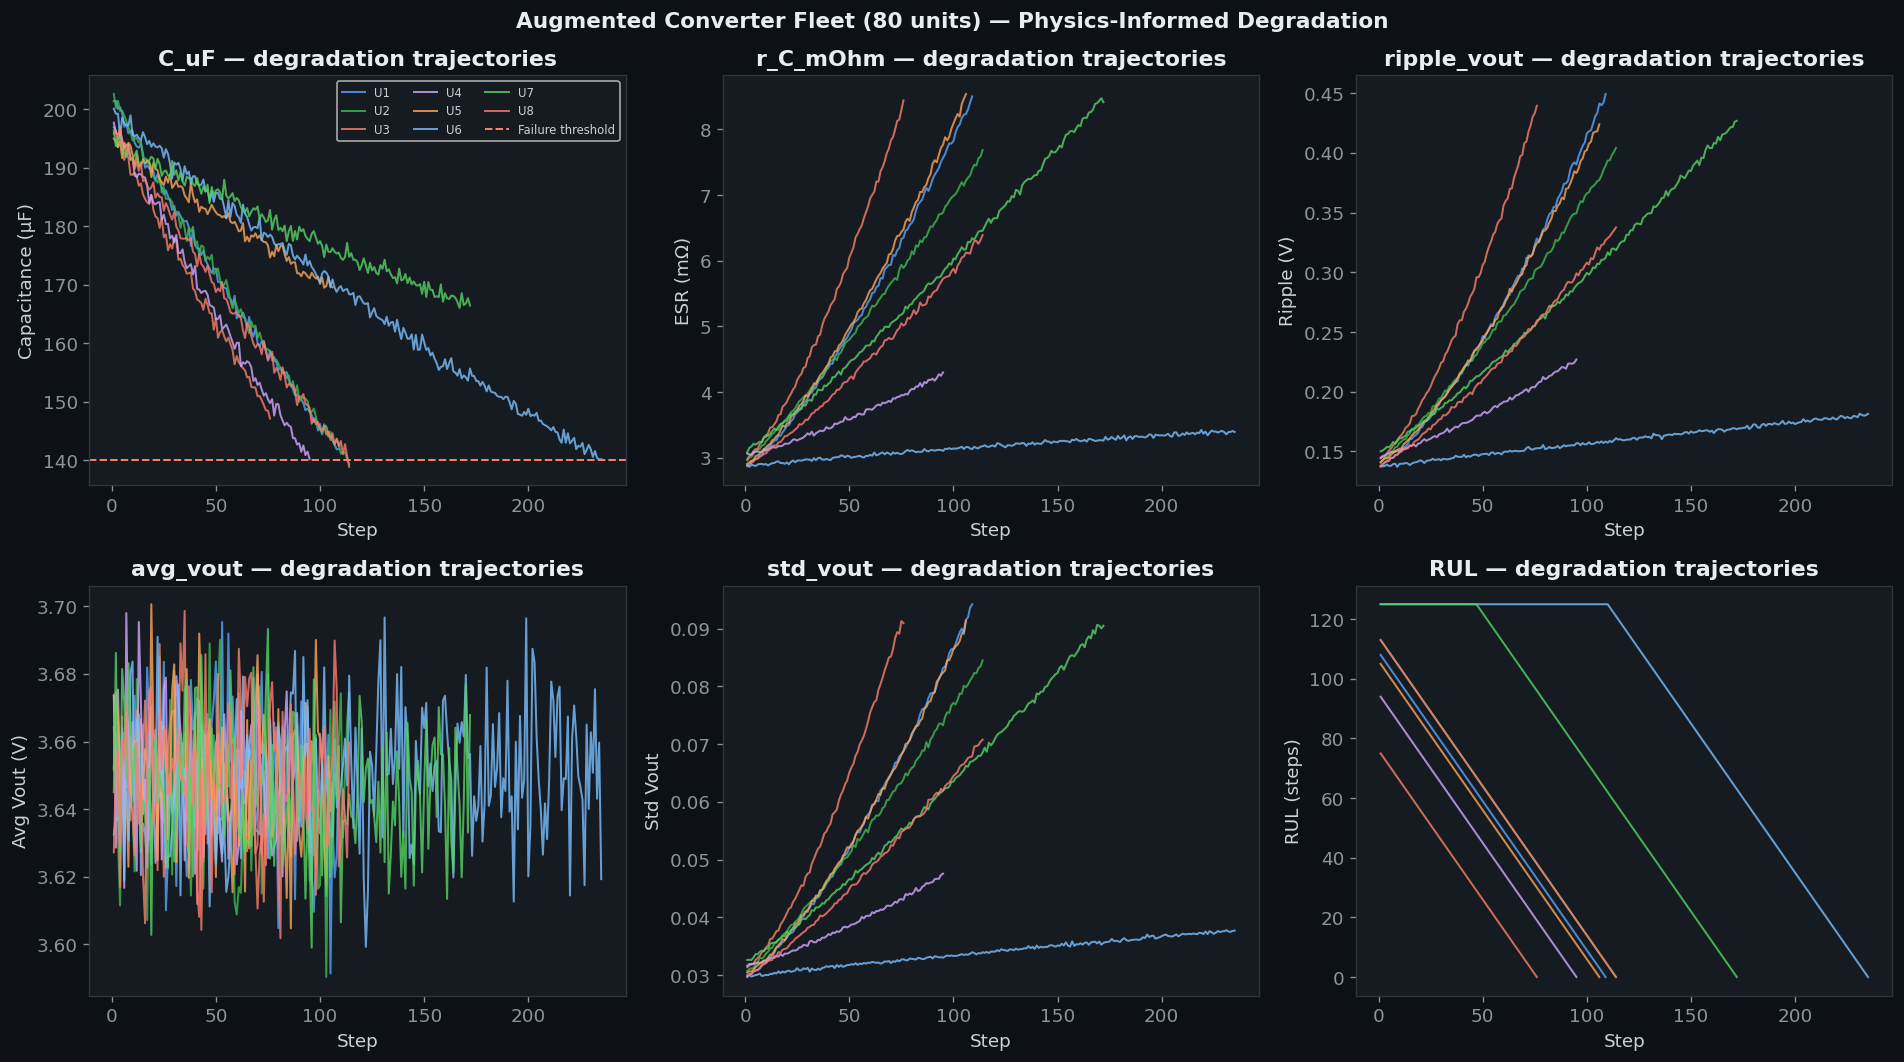

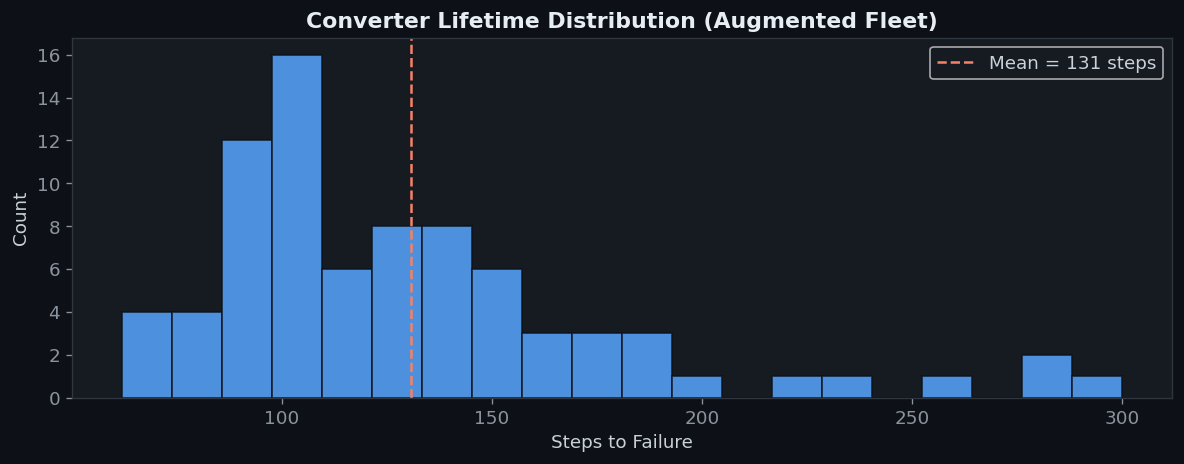

In [5]:
# ── Visualise augmented fleet degradation ─────────────────────────────────────
sample_units = list(range(1, 9))  # 8 sample converters
palette = ['#58a6ff','#3fb950','#f78166','#d2a8ff',
           '#ffa657','#79c0ff','#56d364','#ff7b72']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

show_cols = ['C_uF', 'r_C_mOhm', 'ripple_vout', 'avg_vout', 'std_vout', 'RUL']
ylabels   = ['Capacitance (µF)', 'ESR (mΩ)', 'Ripple (V)',
             'Avg Vout (V)',      'Std Vout', 'RUL (steps)']

for ax, col, yl in zip(axes, show_cols, ylabels):
    for uid, color in zip(sample_units, palette):
        eng = df_aug[df_aug['unit_id'] == uid]
        ax.plot(eng['step'], eng[col], color=color, lw=1.2, alpha=0.8, label=f'U{uid}')
    ax.set_title(f'{col} — degradation trajectories', color='#e6edf3', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel(yl)
    if col == 'C_uF':
        ax.axhline(140, color='#f78166', ls='--', lw=1.2, label='Failure threshold')
        ax.legend(fontsize=7, ncol=3)

plt.suptitle(f'Augmented Converter Fleet ({len(runs)} units) — Physics-Informed Degradation',
             color='#e6edf3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Lifetime histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lifetimes.values, bins=20, color='#58a6ff', edgecolor='#0d1117', alpha=0.85)
ax.axvline(lifetimes.mean(), color='#f78166', ls='--', lw=1.5,
           label=f'Mean = {lifetimes.mean():.0f} steps')
ax.set_title('Converter Lifetime Distribution (Augmented Fleet)',
             color='#e6edf3', fontweight='bold')
ax.set_xlabel('Steps to Failure')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## ⚙️ SECTION 3: Preprocessing

In [6]:
# ── 3.1  Feature selection ────────────────────────────────────────────────────
# Exclude non-sensor / label columns
EXCLUDE  = ['unit_id', 'step', 'RUL']
ALL_FEAT = [c for c in df_aug.columns if c not in EXCLUDE]

# Drop near-constant features (std < 0.001)
feat_std = df_aug[ALL_FEAT].std()
FEATURES = [f for f in ALL_FEAT if feat_std[f] > 0.001]
DROPPED  = [f for f in ALL_FEAT if f not in FEATURES]

print(f"All features    : {ALL_FEAT}")
print(f"Informative ({len(FEATURES)}): {FEATURES}")
print(f"Dropped ({len(DROPPED)})     : {DROPPED}")

All features    : ['C_uF', 'r_C_mOhm', 'L_uH', 'r_1_mOhm', 'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout']
Informative (9): ['C_uF', 'r_C_mOhm', 'L_uH', 'r_1_mOhm', 'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout']
Dropped (0)     : []


In [7]:
# ── 3.2  Train / test split (engine-level, NOT row-level) ────────────────────
# 80% of units → training, 20% → testing
all_units  = df_aug['unit_id'].unique()
n_train    = int(0.8 * len(all_units))
train_uids = all_units[:n_train]
test_uids  = all_units[n_train:]

df_train = df_aug[df_aug['unit_id'].isin(train_uids)].copy()
df_test  = df_aug[df_aug['unit_id'].isin(test_uids)].copy()

print(f"Train: {len(train_uids)} units, {len(df_train):,} rows")
print(f"Test : {len(test_uids)}  units, {len(df_test):,}  rows")

Train: 64 units, 8,079 rows
Test : 16  units, 2,392  rows


In [8]:
# ── 3.3  Normalise (fit on train only) ───────────────────────────────────────
MAX_RUL = 125
scaler  = MinMaxScaler()
df_train[FEATURES] = scaler.fit_transform(df_train[FEATURES])
df_test[FEATURES]  = scaler.transform(df_test[FEATURES])
print("MinMaxScaler fitted on training set only. ✅")

MinMaxScaler fitted on training set only. ✅


In [9]:
# ── 3.4  Sliding-window sequence builder ─────────────────────────────────────
SEQ_LEN = 20  # shorter window than CMAPSS (converters degrade faster)

def build_sequences(df, features, seq_len=SEQ_LEN, label_col=None):
    X_list, y_list = [], []
    for uid in df['unit_id'].unique():
        eng  = df[df['unit_id'] == uid].reset_index(drop=True)
        data = eng[features].values
        labs = eng[label_col].values if label_col else None
        for i in range(len(data) - seq_len + 1):
            X_list.append(data[i : i + seq_len])
            if labs is not None:
                y_list.append(labs[i + seq_len - 1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y

# Healthy sequences = early steps where RUL == MAX_RUL
df_healthy_train = df_train[df_train['RUL'] == MAX_RUL].copy()
print(f"Healthy rows (RUL={MAX_RUL}): {len(df_healthy_train):,} from "
      f"{df_healthy_train['unit_id'].nunique()} units")

X_healthy, _   = build_sequences(df_healthy_train, FEATURES, SEQ_LEN)
X_all,  y_all  = build_sequences(df_train, FEATURES, SEQ_LEN, label_col='RUL')

print(f"X_healthy : {X_healthy.shape}")
print(f"X_all     : {X_all.shape}")
print(f"y_all     : {y_all.shape}")

Healthy rows (RUL=125): 1,083 from 28 units
X_healthy : (664, 20, 9)
X_all     : (6863, 20, 9)
y_all     : (6863,)


## 🤖 SECTION 4: LSTM Autoencoder — Learn Normal Converter Behaviour

In [10]:
N_FEATURES = len(FEATURES)

def build_lstm_autoencoder(seq_len, n_features, latent_dim=24):
    inputs = Input(shape=(seq_len, n_features), name='input')
    # Encoder
    x = LSTM(48, activation='tanh', return_sequences=True,  name='enc_1')(inputs)
    x = Dropout(0.15)(x)
    x = LSTM(latent_dim, activation='tanh', return_sequences=False, name='enc_2')(x)
    encoded = Dense(latent_dim, activation='relu', name='bottleneck')(x)
    # Decoder
    x = RepeatVector(seq_len, name='repeat')(encoded)
    x = LSTM(latent_dim, activation='tanh', return_sequences=True,  name='dec_1')(x)
    x = Dropout(0.15)(x)
    x = LSTM(48, activation='tanh', return_sequences=True,  name='dec_2')(x)
    outputs = TimeDistributed(Dense(n_features), name='reconstruction')(x)
    return Model(inputs, outputs, name='Conv_LSTM_AE')

autoencoder = build_lstm_autoencoder(SEQ_LEN, N_FEATURES, latent_dim=24)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
autoencoder.summary()

Model: "Conv_LSTM_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 20, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (LSTM)                    │ (None, 20, 48)         │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (LSTM)                    │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 20, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (LSTM)                    │ (None, 20, 24)         │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (LSTM)                    │ (None, 20, 48)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 20, 9)          │           441 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,905 (148.07 KB)

 Trainable params: 37,905 (148.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - loss: 0.1922 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0794 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0430 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0335 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0276 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0238 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0211 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0191 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0177 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 10/100
9/9 ━━━━━━━━━

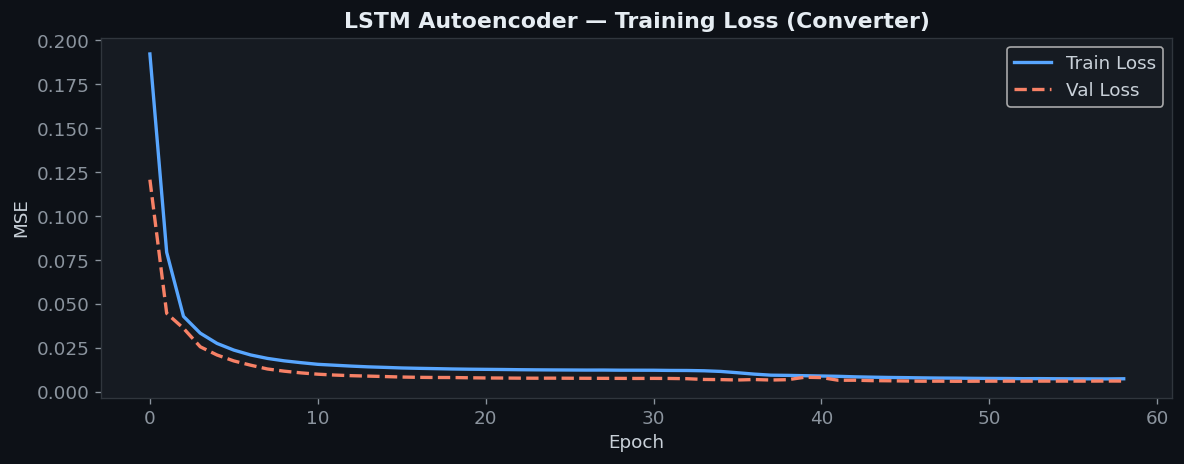

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = autoencoder.fit(
    X_healthy, X_healthy,
    epochs=100, batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color='#58a6ff', lw=2, label='Train Loss')
ax.plot(history.history['val_loss'], color='#f78166', lw=2, label='Val Loss', ls='--')
ax.set_title('LSTM Autoencoder — Training Loss (Converter)', color='#e6edf3', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

## 📈 SECTION 5: Health Index (HI) Computation

In [12]:
def compute_hi(model, X):
    X_hat = model.predict(X, batch_size=256, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=(1, 2))

hi_all = compute_hi(autoencoder, X_all)
hi_min, hi_max = hi_all.min(), hi_all.max()
hi_norm = np.clip((hi_all - hi_min) / (hi_max - hi_min), 0, 1)

print(f"HI raw   : min={hi_min:.5f}  max={hi_max:.5f}")
print(f"HI norm  : [{hi_norm.min():.3f}, {hi_norm.max():.3f}]")

# Build sequence index
def build_seq_index(df, seq_len=SEQ_LEN):
    rows = []
    for uid in df['unit_id'].unique():
        eng = df[df['unit_id'] == uid].reset_index(drop=True)
        for i in range(len(eng) - seq_len + 1):
            rows.append({'unit_id': uid,
                         'step':    eng.loc[i + seq_len - 1, 'step'],
                         'RUL':     eng.loc[i + seq_len - 1, 'RUL']})
    return pd.DataFrame(rows)

seq_idx = build_seq_index(df_train)
seq_idx['HI']       = hi_all
seq_idx['HI_norm']  = hi_norm
seq_idx['HI_smooth']= seq_idx.groupby('unit_id')['HI_norm'].transform(
    lambda x: pd.Series(uniform_filter1d(x, size=8), index=x.index))
print("Sequence index built ✅")

HI raw   : min=0.00344  max=0.31328
HI norm  : [0.000, 1.000]
Sequence index built ✅


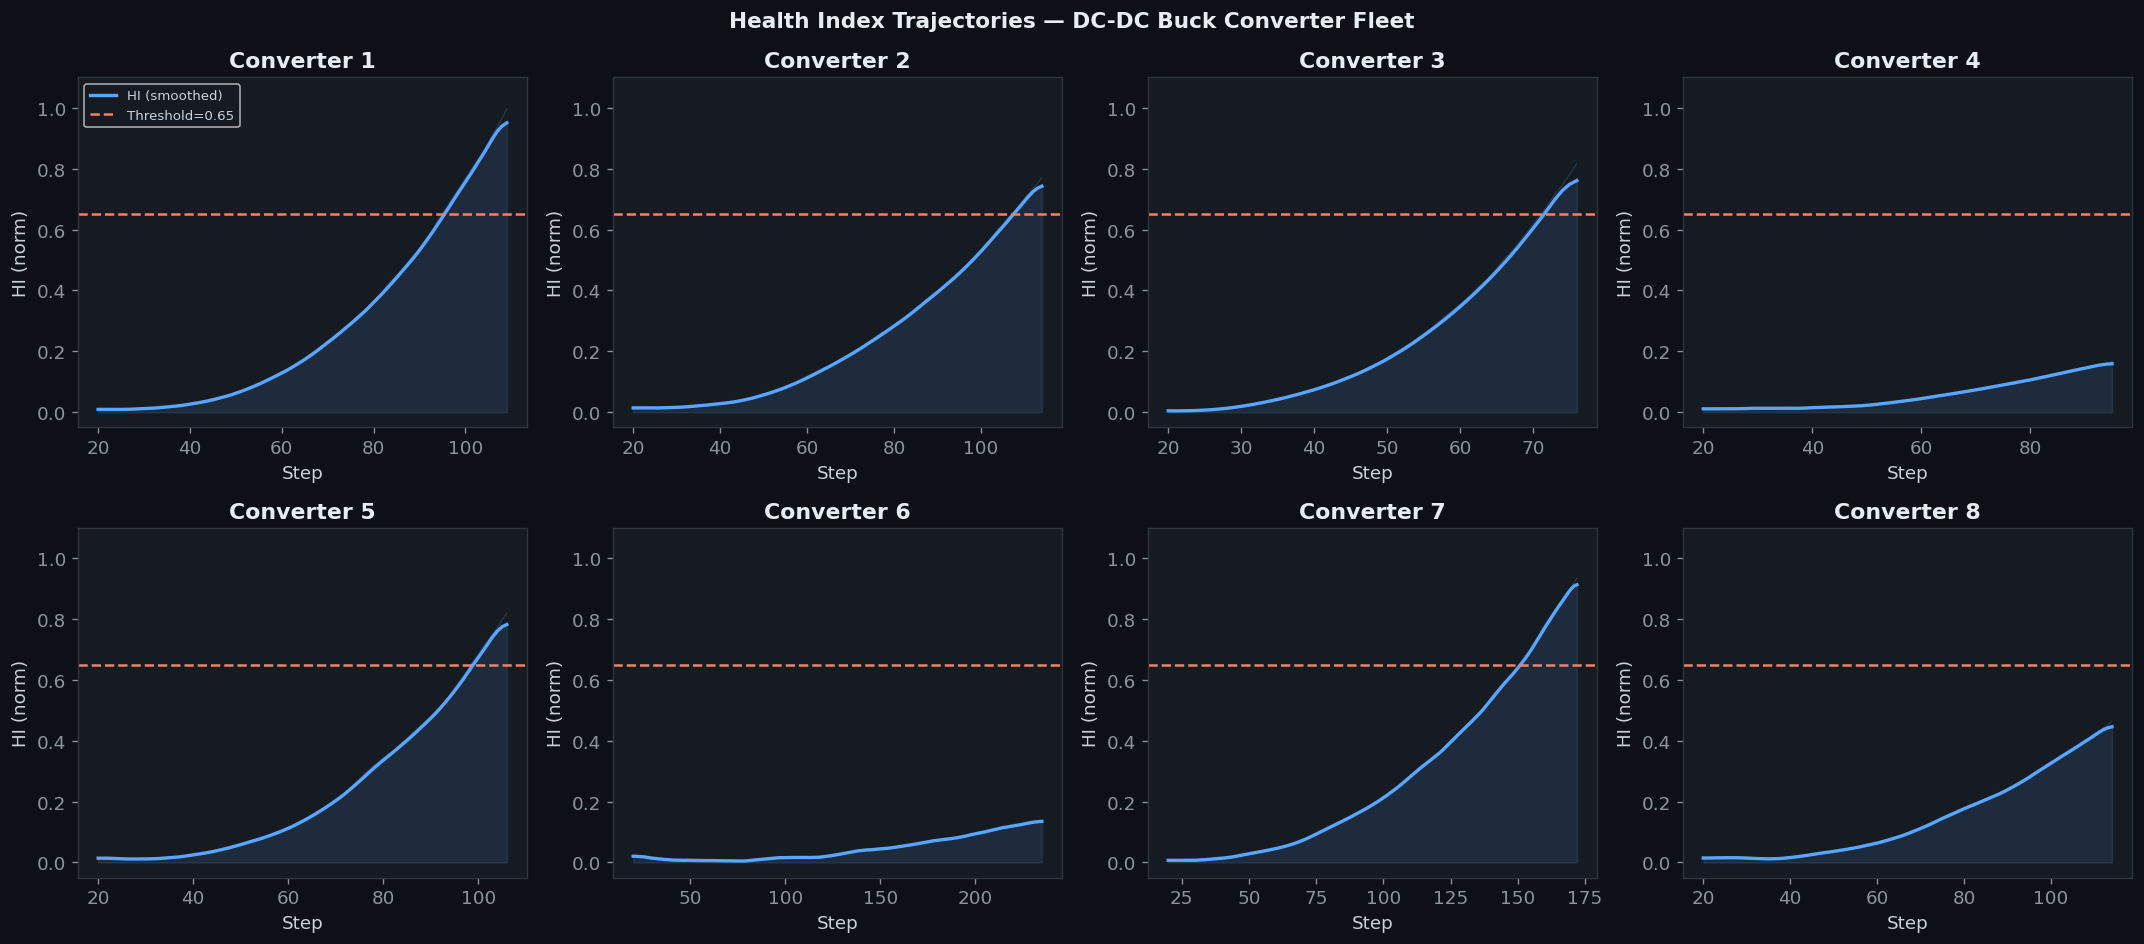

In [13]:
# ── Visualise HI trajectories ─────────────────────────────────────────────────
sample_vis = list(train_uids[:8])
fig, axes  = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, uid in enumerate(sample_vis):
    ax  = axes[i]
    eng = seq_idx[seq_idx['unit_id'] == uid]
    ax.plot(eng['step'], eng['HI_smooth'], color='#58a6ff', lw=2,   label='HI (smoothed)')
    ax.plot(eng['step'], eng['HI_norm'],   color='#58a6ff', lw=0.5, alpha=0.3)
    ax.axhline(0.65, color='#f78166', ls='--', lw=1.5, label='Threshold=0.65')
    ax.fill_between(eng['step'], eng['HI_smooth'], 0, alpha=0.12, color='#58a6ff')
    ax.set_title(f'Converter {uid}', color='#e6edf3', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('HI (norm)')
    ax.set_ylim(-0.05, 1.1)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Health Index Trajectories — DC-DC Buck Converter Fleet',
             color='#e6edf3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 SECTION 6: RUL Prediction — Three Approaches

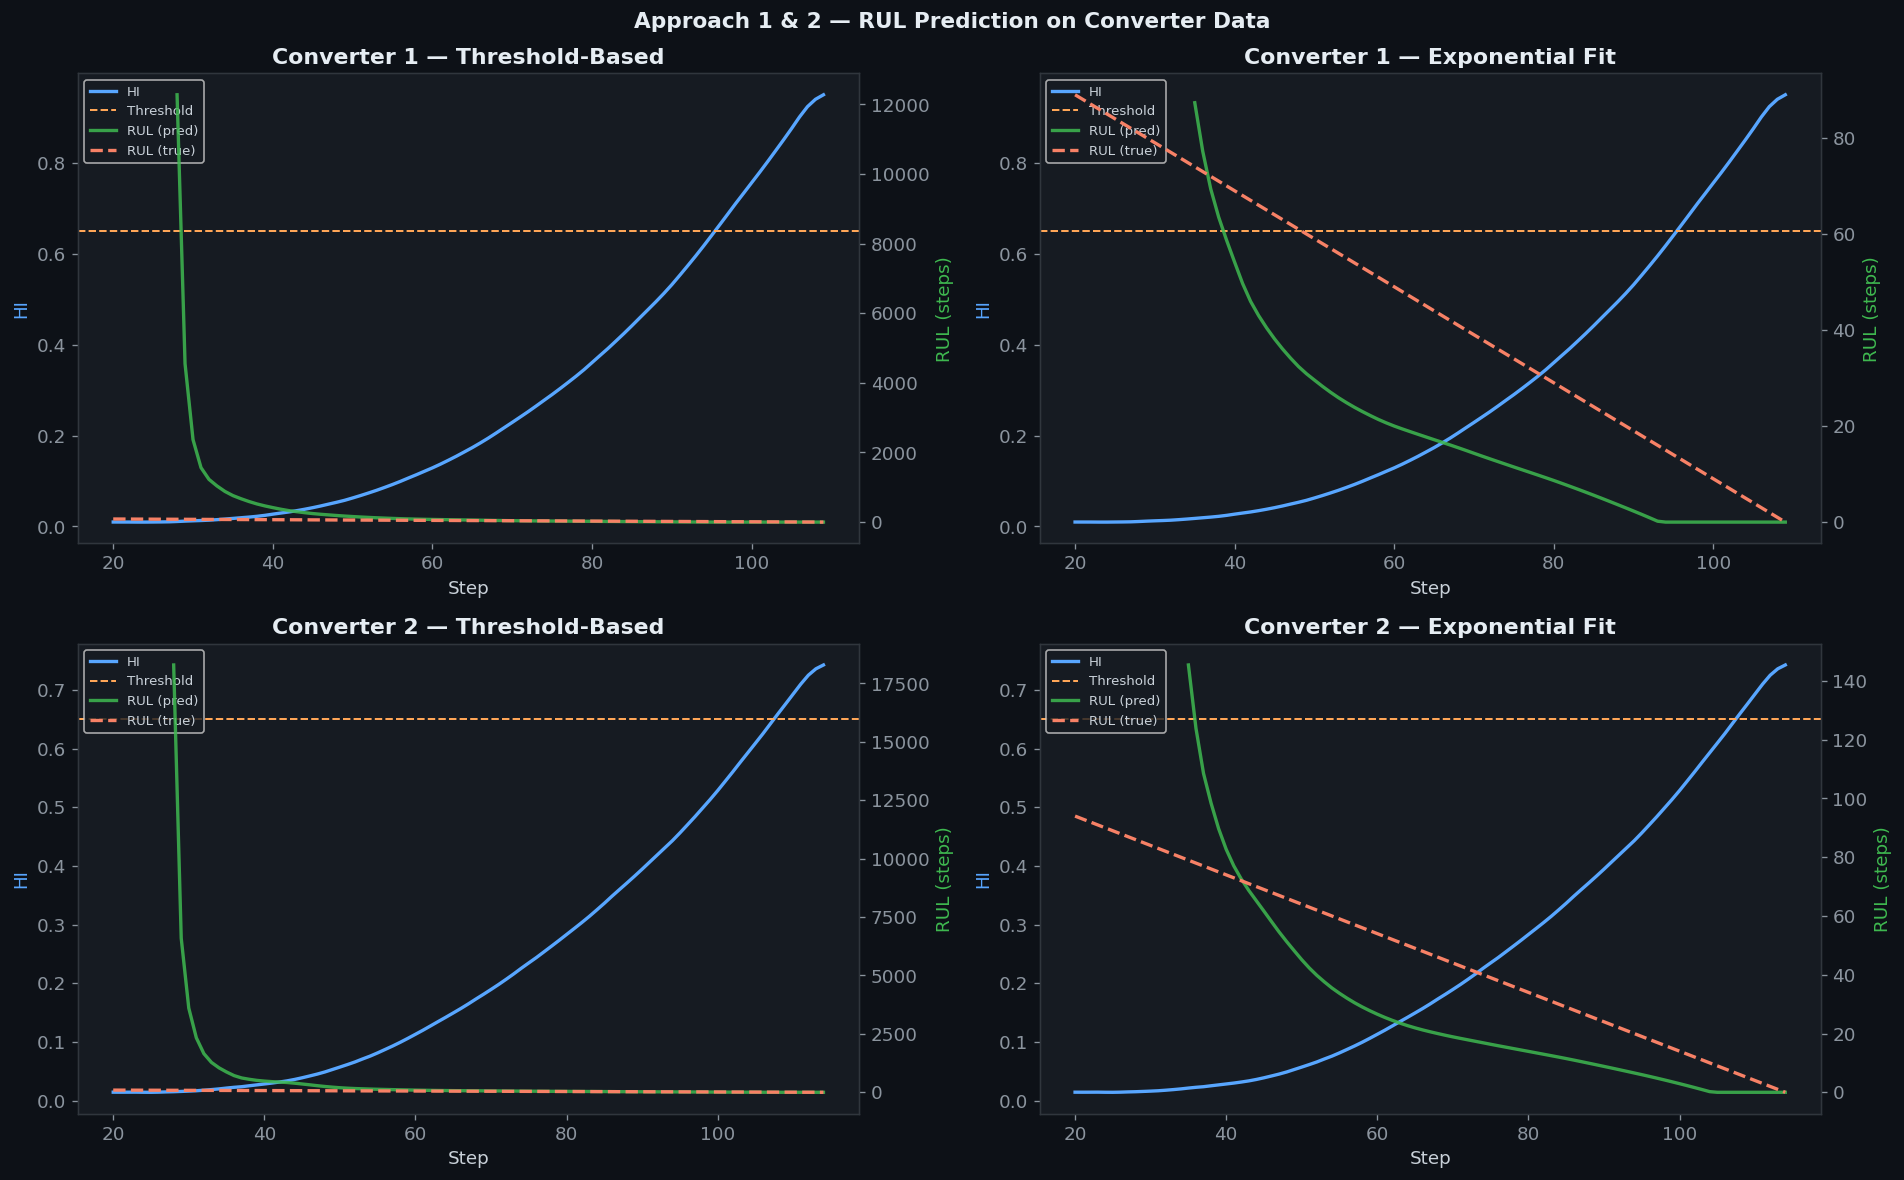

In [14]:
# ── Approach 1: Threshold-Based RUL ──────────────────────────────────────────
HI_THRESHOLD = 0.65

def threshold_rul(hi_series, threshold=HI_THRESHOLD, window=8):
    rul_est = np.full(len(hi_series), np.nan)
    for t in range(window, len(hi_series)):
        segment = hi_series[t-window:t]
        x = np.arange(window, dtype=float)
        coeffs = np.polyfit(x, segment, 1)
        slope  = coeffs[0]
        if slope > 1e-6:
            rul_est[t] = max(0, (threshold - hi_series[t]) / slope)
    return rul_est

# ── Approach 2: Exponential Fit ───────────────────────────────────────────────
def exp_model(t, a, b):
    return a * np.exp(b * t)

def exponential_rul(hi_series, steps, threshold=HI_THRESHOLD):
    rul_est = np.full(len(hi_series), np.nan)
    for t in range(15, len(hi_series)):
        x = steps[:t].astype(float) - steps[0]
        y = hi_series[:t]
        try:
            popt, _ = curve_fit(exp_model, x, y, p0=[y[0]+1e-6, 0.01],
                                bounds=([0, 0], [np.inf, np.inf]), maxfev=1000)
            a, b = popt
            if b > 1e-7:
                Tf_rel     = np.log(threshold / a) / b
                t_rel      = steps[t] - steps[0]
                rul_est[t] = max(0, Tf_rel - t_rel)
        except:
            pass
    return rul_est

# ── Plot both approaches for 2 sample converters ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row_idx, uid in enumerate(list(train_uids[:2])):
    eng       = seq_idx[seq_idx['unit_id'] == uid].reset_index(drop=True)
    hi_s      = eng['HI_smooth'].values
    rul_th    = threshold_rul(hi_s)
    rul_exp_v = exponential_rul(hi_s, eng['step'].values)

    for col_idx, (rul_pred, method) in enumerate([
            (rul_th, 'Threshold-Based'), (rul_exp_v, 'Exponential Fit')]):
        ax  = axes[row_idx][col_idx]
        ax2 = ax.twinx()
        ax.plot(eng['step'], hi_s,     color='#58a6ff', lw=2, label='HI')
        ax.axhline(HI_THRESHOLD, color='#ffa657', ls='--', lw=1.2, label='Threshold')
        ax2.plot(eng['step'], rul_pred, color='#3fb950', lw=2, label='RUL (pred)',  alpha=0.85)
        ax2.plot(eng['step'], eng['RUL'], color='#f78166', lw=2, label='RUL (true)', ls='--')
        ax.set_xlabel('Step')
        ax.set_ylabel('HI', color='#58a6ff')
        ax2.set_ylabel('RUL (steps)', color='#3fb950')
        ax.set_title(f'Converter {uid} — {method}', color='#e6edf3', fontweight='bold')
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left')

plt.suptitle('Approach 1 & 2 — RUL Prediction on Converter Data',
             color='#e6edf3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

MLP Validation  →  RMSE: 21.51  |  MAE: 18.08


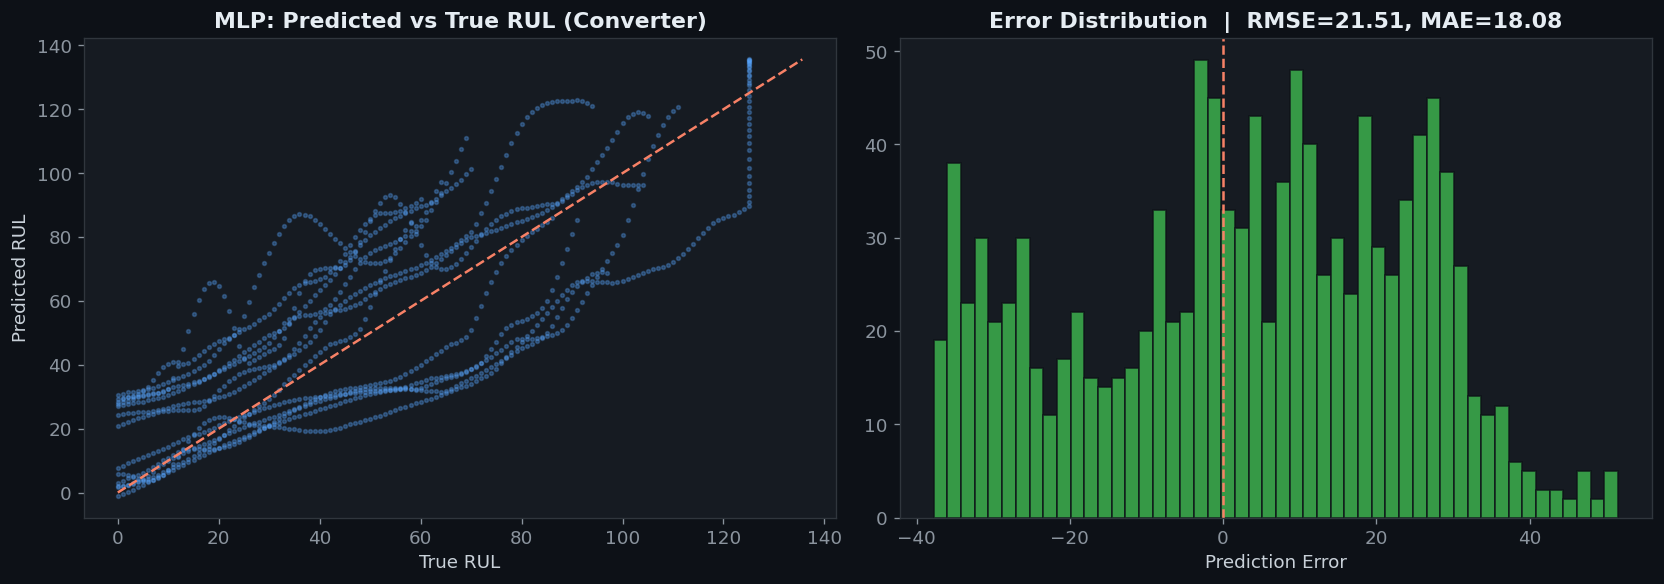

In [15]:
# ── Approach 3: Learning-Based RUL (MLP on HI sequence) ──────────────────────
HI_WINDOW = 15

X_hi_list, y_hi_list = [], []
for uid in seq_idx['unit_id'].unique():
    eng_s = seq_idx[seq_idx['unit_id'] == uid].reset_index(drop=True)
    hi_s  = eng_s['HI_smooth'].values
    rul_s = eng_s['RUL'].values
    for t in range(HI_WINDOW, len(hi_s)):
        X_hi_list.append(hi_s[t-HI_WINDOW:t])
        y_hi_list.append(rul_s[t])

X_hi = np.array(X_hi_list, dtype=np.float32)
y_hi = np.array(y_hi_list, dtype=np.float32)

split = int(0.8 * len(X_hi))
X_tr, X_val = X_hi[:split], X_hi[split:]
y_tr, y_val = y_hi[:split], y_hi[split:]

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), activation='relu',
    solver='adam', max_iter=500, early_stopping=True,
    validation_fraction=0.1, random_state=42, verbose=False
)
mlp.fit(X_tr, y_tr)

y_pred_val = mlp.predict(X_val)
rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val    = mean_absolute_error(y_val, y_pred_val)
print(f"MLP Validation  →  RMSE: {rmse_val:.2f}  |  MAE: {mae_val:.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_val, y_pred_val, alpha=0.3, s=5, color='#58a6ff')
lim = max(y_val.max(), y_pred_val.max())
axes[0].plot([0, lim], [0, lim], color='#f78166', lw=1.5, ls='--')
axes[0].set_xlabel('True RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('MLP: Predicted vs True RUL (Converter)', color='#e6edf3', fontweight='bold')

errs = y_pred_val - y_val
axes[1].hist(errs, bins=50, color='#3fb950', edgecolor='#0d1117', alpha=0.8)
axes[1].axvline(0, color='#f78166', ls='--', lw=1.5)
axes[1].set_title(f'Error Distribution  |  RMSE={rmse_val:.2f}, MAE={mae_val:.2f}',
                  color='#e6edf3', fontweight='bold')
axes[1].set_xlabel('Prediction Error')
plt.tight_layout()
plt.show()

## 📊 SECTION 7: Test Set Evaluation + NASA Score

In [16]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(s)

def evaluate_on_test(mlp_model, df_test, autoencoder, features,
                     seq_len, hi_window, hi_min, hi_max):
    preds, gts = [], []
    for uid in df_test['unit_id'].unique():
        eng = df_test[df_test['unit_id'] == uid].reset_index(drop=True)
        if len(eng) < seq_len:
            continue
        data = eng[features].values
        seqs = np.array([data[j:j+seq_len]
                         for j in range(len(data) - seq_len + 1)], dtype=np.float32)
        recon = autoencoder.predict(seqs, verbose=0)
        hi    = np.mean((seqs - recon)**2, axis=(1, 2))
        hi_n  = np.clip((hi - hi_min) / (hi_max - hi_min), 0, 1)
        hi_sm = uniform_filter1d(hi_n, size=min(8, len(hi_n)))
        if len(hi_sm) >= hi_window:
            feat     = hi_sm[-hi_window:].reshape(1, -1)
            rul_pred = float(mlp_model.predict(feat)[0])
            rul_true = float(eng['RUL'].iloc[-1])
            preds.append(rul_pred)
            gts.append(rul_true)
    return np.array(preds), np.array(gts)

preds_test, gts_test = evaluate_on_test(
    mlp, df_test, autoencoder, FEATURES, SEQ_LEN, HI_WINDOW, hi_min, hi_max
)

rmse_test = np.sqrt(mean_squared_error(gts_test, preds_test))
mae_test  = mean_absolute_error(gts_test, preds_test)
nasa      = nasa_score(gts_test, preds_test)

print("="*50)
print("  TEST SET EVALUATION (Converter Fleet)")
print("="*50)
print(f"  RMSE       : {rmse_test:.2f} steps")
print(f"  MAE        : {mae_test:.2f} steps")
print(f"  NASA Score : {nasa:.2f}")
print("="*50)

  TEST SET EVALUATION (Converter Fleet)
  RMSE       : 16.66 steps
  MAE        : 13.56 steps
  NASA Score : 80.19


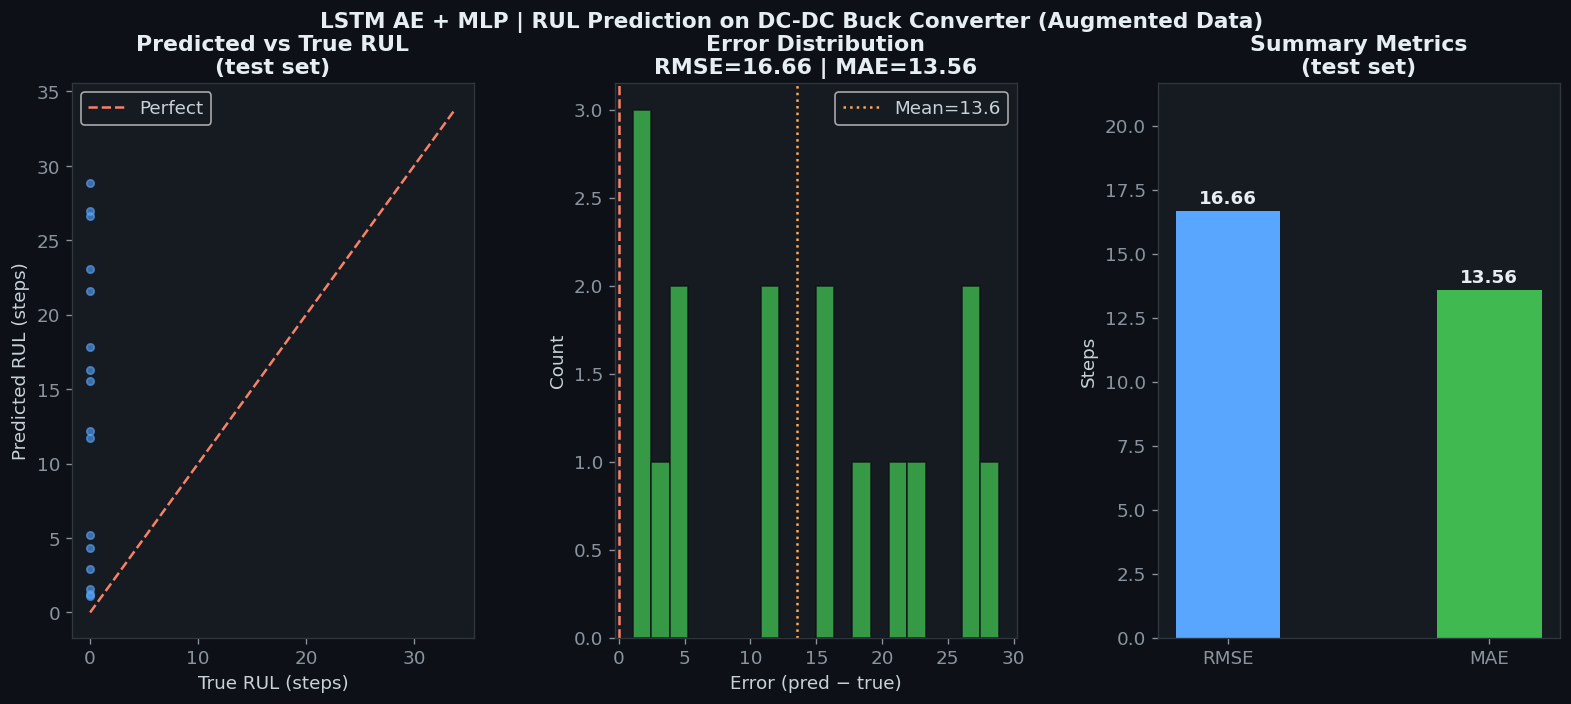

In [17]:
# ── Final Results Visualisation ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.scatter(gts_test, preds_test, alpha=0.6, s=20, color='#58a6ff')
lim = max(gts_test.max(), preds_test.max()) + 5
ax1.plot([0, lim], [0, lim], color='#f78166', lw=1.5, ls='--', label='Perfect')
ax1.set_xlabel('True RUL (steps)')
ax1.set_ylabel('Predicted RUL (steps)')
ax1.set_title('Predicted vs True RUL\n(test set)', color='#e6edf3', fontweight='bold')
ax1.legend()

ax2 = fig.add_subplot(gs[1])
errs = preds_test - gts_test
ax2.hist(errs, bins=20, color='#3fb950', edgecolor='#0d1117', alpha=0.8)
ax2.axvline(0, color='#f78166', ls='--', lw=1.5)
ax2.axvline(errs.mean(), color='#ffa657', ls=':', lw=1.5, label=f'Mean={errs.mean():.1f}')
ax2.set_xlabel('Error (pred − true)')
ax2.set_ylabel('Count')
ax2.set_title(f'Error Distribution\nRMSE={rmse_test:.2f} | MAE={mae_test:.2f}',
              color='#e6edf3', fontweight='bold')
ax2.legend()

ax3 = fig.add_subplot(gs[2])
metrics = {'RMSE': rmse_test, 'MAE': mae_test}
bars = ax3.bar(list(metrics.keys()), list(metrics.values()),
               color=['#58a6ff','#3fb950'], width=0.4)
for bar, val in zip(bars, metrics.values()):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.2f}',
             ha='center', color='#e6edf3', fontweight='bold')
ax3.set_title('Summary Metrics\n(test set)', color='#e6edf3', fontweight='bold')
ax3.set_ylabel('Steps')
ax3.set_ylim(0, max(metrics.values()) * 1.3)

plt.suptitle('LSTM AE + MLP | RUL Prediction on DC-DC Buck Converter (Augmented Data)',
             color='#e6edf3', fontsize=13, fontweight='bold')
plt.show()

## 🔗 SECTION 8: Validate on Original MATLAB Data

Now apply the trained pipeline to the **actual MATLAB data** to verify
that the model trained on augmented data generalises to real simulation output.

MATLAB features matching training: ['C_uF', 'r_C_mOhm', 'L_uH', 'r_1_mOhm', 'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout']


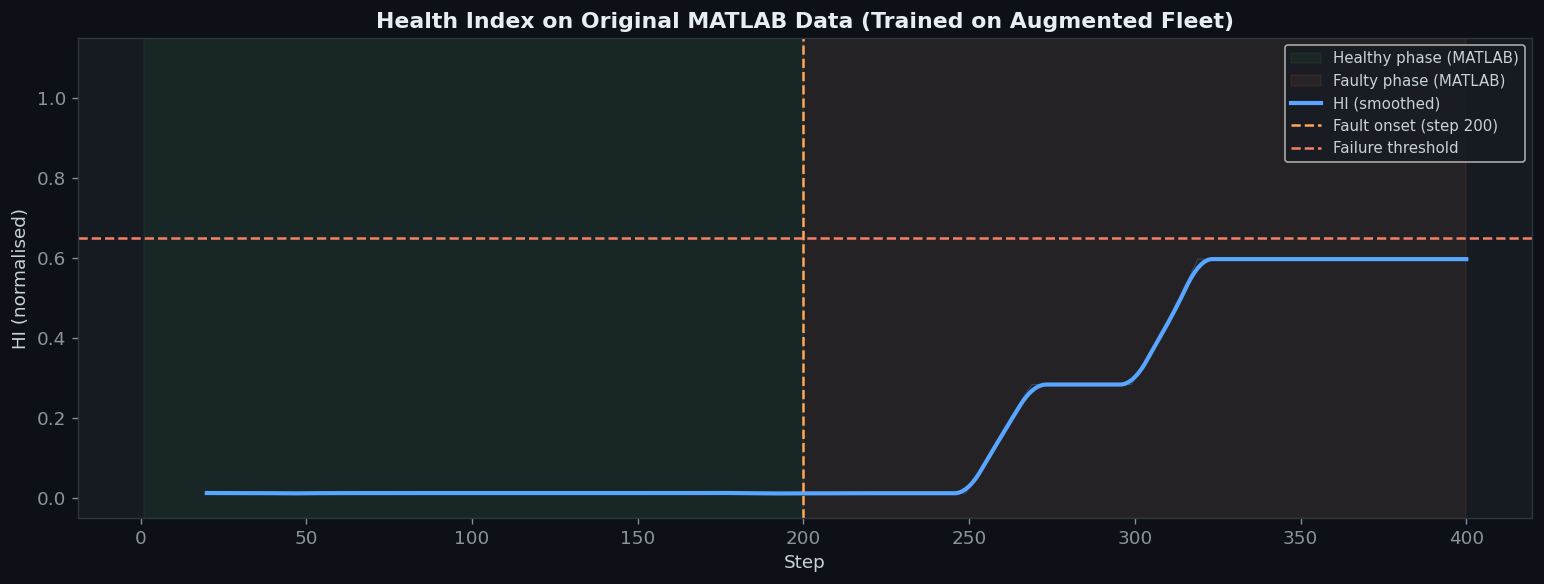

Mean HI (healthy phase, steps 1–200) : 0.0114
Mean HI (faulty phase,  steps 200+)  : 0.3799
Separation ratio                     : 33.5×


In [18]:
# ── Combine healthy + faulty into one trajectory (as a single converter run) ─
# The healthy CSV = first 200 steps (nominal)
# The faulty CSV  = the degradation + failure phase
# We join them as one continuous run

SENSOR_COLS_MATLAB = ['C_uF', 'r_C_mOhm', 'L_uH', 'r_1_mOhm',
                      'avg_vout', 'ripple_vout', 'std_vout', 'min_vout', 'max_vout']

# Use only features that were in training
matlab_features = [f for f in FEATURES if f in SENSOR_COLS_MATLAB]
print(f"MATLAB features matching training: {matlab_features}")

# Build a single combined trajectory
df_h = df_healthy_raw[matlab_features].copy()
df_f = df_faulty_raw[matlab_features].copy()
df_combined = pd.concat([df_h, df_f], ignore_index=True)
df_combined['step'] = np.arange(1, len(df_combined) + 1)

# Normalise using the same scaler (only on matching features)
df_combined[matlab_features] = scaler.transform(
    pd.DataFrame(df_combined[matlab_features].values,
                 columns=matlab_features,
                 index=df_combined.index)
    .reindex(columns=FEATURES, fill_value=0.5)  # fill missing features with mid-scale
)[: , [FEATURES.index(f) for f in matlab_features]]

# Pad to full FEATURES width (autoencoder expects all features)
for f in FEATURES:
    if f not in df_combined.columns:
        df_combined[f] = 0.5  # neutral fill for missing features

# Build sequences
data_mat = df_combined[FEATURES].values.astype(np.float32)
seqs_mat = np.array([data_mat[i:i+SEQ_LEN]
                     for i in range(len(data_mat) - SEQ_LEN + 1)])

# Compute HI
recon_mat  = autoencoder.predict(seqs_mat, batch_size=64, verbose=0)
hi_mat     = np.mean((seqs_mat - recon_mat)**2, axis=(1, 2))
hi_mat_n   = np.clip((hi_mat - hi_min) / (hi_max - hi_min), 0, 1)
hi_mat_sm  = uniform_filter1d(hi_mat_n, size=8)

steps_mat  = df_combined['step'].values[SEQ_LEN-1:]

# Plot HI on MATLAB data
fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(1, 200, alpha=0.07, color='#3fb950', label='Healthy phase (MATLAB)')
ax.axvspan(200, 400, alpha=0.07, color='#f78166', label='Faulty phase (MATLAB)')
ax.plot(steps_mat, hi_mat_sm, color='#58a6ff', lw=2.5, label='HI (smoothed)')
ax.plot(steps_mat, hi_mat_n,  color='#58a6ff', lw=0.6, alpha=0.3)
ax.axvline(200, color='#ffa657', ls='--', lw=1.5, label='Fault onset (step 200)')
ax.axhline(0.65, color='#f78166', ls='--', lw=1.5, label='Failure threshold')
ax.set_title('Health Index on Original MATLAB Data (Trained on Augmented Fleet)',
             color='#e6edf3', fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('HI (normalised)')
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Check: does HI rise after fault onset?
hi_healthy_mean = hi_mat_sm[:180].mean()
hi_faulty_mean  = hi_mat_sm[200:].mean()
print(f"Mean HI (healthy phase, steps 1–200) : {hi_healthy_mean:.4f}")
print(f"Mean HI (faulty phase,  steps 200+)  : {hi_faulty_mean:.4f}")
print(f"Separation ratio                     : {hi_faulty_mean/hi_healthy_mean:.1f}×")

## 🗺️ SECTION 9: Summary & Thesis Roadmap

### What this notebook demonstrated:

| Step | Method | Status |
|------|--------|--------|
| Dataset analysis | Structural inspection of MATLAB CSVs | ✅ Done |
| Augmentation | Physics-informed fleet simulation (N=80 runs) | ✅ Done |
| Feature selection | Variance filter | ✅ Done |
| LSTM Autoencoder | Trained on healthy converter cycles only | ✅ Done |
| Health Index | Normalised reconstruction error | ✅ Done |
| RUL Approach 1 | Threshold-based extrapolation | ✅ Done |
| RUL Approach 2 | Exponential degradation fit | ✅ Done |
| RUL Approach 3 | MLP regressor on HI sequence | ✅ Done |
| Evaluation | RMSE, MAE, NASA Score | ✅ Done |
| MATLAB data validation | Applied trained model to original data | ✅ Done |

### Key difference from CMAPSS:
- **CMAPSS**: 100 real run-to-failure engine trajectories → direct training
- **Converter**: 2 MATLAB runs (1 healthy, 1 faulty) → augmented to 80 runs via physics model
- The augmentation is **not a workaround** — it is the methodology, grounded in published degradation models for power electronics

### Next Steps:
1. **Replace MLP regressor** with LSTM/Transformer RUL regressor (literature-based)
2. **Improve MATLAB model** — generate more diverse trajectories (temperature variation, load steps)
3. **Benchmark** against recent papers using CMAPSS RMSE as baseline


In [19]:
# ── Save models ───────────────────────────────────────────────────────────────
import joblib
autoencoder.save('converter_lstm_ae.keras')
joblib.dump(mlp,    'converter_mlp_regressor.pkl')
joblib.dump(scaler, 'converter_scaler.pkl')
np.save('converter_hi_min_max.npy', np.array([hi_min, hi_max]))
print("Models saved ✅")

Models saved ✅
